## 5.0 Contexto del notebook

Este notebook continúa lo aprendido en el Notebook 4:  
**las métricas describen comportamiento, pero no definen decisiones.**

Aquí damos el salto operativo:

> convertir **señales** (probabilidades / scores) en **políticas explícitas** usando thresholds.

### Artefactos que entran
Trabajaremos con outputs ya generados (sin reentrenar):

- `y_test` (verdad terreno)
- `y_proba` (probabilidades por clase) y/o `scores` (señal cruda)
- *(opcional)* `conf_df` si quieres reutilizar el análisis fila a fila

### Objetivo del notebook
- Definir un **evento operativo** (ej.: “vino bueno” vs “no bueno”).
- Construir una **regla de decisión** basada en threshold.
- Medir el trade-off real entre errores con **precision** y **recall**.
- Demostrar que:

📌 **El threshold es una decisión de negocio, no un ajuste técnico.**

---
---
---

## 5.1 Pasar de multiclase a “evento operativo”

Hasta ahora el modelo predice **calidades de vino** (3 a 9).  
Eso es útil para análisis, pero **no es directamente accionable**.

En la práctica, una organización no decide sobre “todas las clases”,  
decide sobre **eventos concretos**.

Ejemplos reales:
- ¿Este vino es **lo suficientemente bueno** para aprobarlo?
- ¿Este vino es **riesgoso** y requiere revisión?
- ¿Este vino entra o no en una categoría comercial?

Por eso, el primer paso operativo es **reformular el problema**.

<br>

### De clasificación multiclase a evento binario

Aquí tomamos una decisión explícita y documentada:

> **Evento operativo:**  
> Un vino se considera **“bueno”** si su calidad es **mayor o igual a 7**.

Esto implica:
- Clases **7, 8 y 9** → evento positivo (`1`)
- Clases **3, 4, 5 y 6** → evento negativo (`0`)

No estamos diciendo que esta sea “la mejor” definición.  
Estamos diciendo que **es una definición clara**, necesaria para avanzar.

📌 Sin evento operativo definido, **no existen thresholds**.  
📌 Sin threshold, **no existe política**.

<br>

### Qué cambia a partir de aquí

A partir de este punto:
- dejamos de evaluar “qué clase predice el modelo”,
- empezamos a evaluar **si detecta correctamente el evento**.

Esto nos permitirá:
- hablar de **precision y recall**,
- mover thresholds conscientemente,
- y discutir errores en términos de **impacto real**, no solo de métricas.

En el siguiente bloque construiremos la variable binaria (`y_true_bin`)  
que representa este evento operativo.

---
---
---

### Carga de artefactos del modelo

Este notebook **no entrena modelos**.  
Carga los artefactos generados en el Notebook 3 para analizarlos desde el punto de vista de métricas.

Los objetos cargados representan:
- resultados finales del modelo,
- señales ya producidas,
- datos inmutables para el análisis.

In [6]:
import numpy as np

# Carga de artefactos persistidos en el Notebook 3
y_test = np.load("../artifacts/y_test.npy")
y_pred = np.load("../artifacts/y_pred.npy")
y_proba = np.load("../artifacts/y_proba.npy")
scores = np.load("../artifacts/scores.npy")

y_test.shape, y_pred.shape, y_proba.shape, scores.shape

((975,), (975,), (975, 7), (975, 7))

---
---
---

## 5.1 Construcción del evento operativo

En este bloque se traduce la **variable multiclase** (`y_test`) a un **evento binario accionable**.

Definimos explícitamente qué significa un resultado **positivo** desde el punto de vista operativo:
- `1` → vino considerado **bueno** (calidad ≥ 7)
- `0` → vino **no bueno** (calidad < 7)

Este paso es clave porque:
- las métricas como *precision* y *recall* **solo existen** una vez definido el evento,
- los thresholds **no se aplican a clases**, se aplican a eventos,
- toda política de decisión parte de esta definición.

📌 Aquí no se optimiza nada.  
📌 Solo se fija, de forma explícita, **qué problema estamos decidiendo**.

In [7]:
# Construcción del evento operativo (vino "bueno")
# 1 = calidad >= 7, 0 = resto
y_true_bin = (y_test >= 7).astype(int)

# Verificación rápida
y_true_bin[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

> Este resultado muestra la **traducción directa de la calidad real del vino a un evento binario**.
>
> Cada posición del arreglo corresponde a un vino del conjunto de test:
>
> * `1` indica que ese vino tiene **calidad 7 o superior** y, por lo tanto, se considera **“vino bueno”** según la definición operativa.
> * `0` indica que el vino tiene **calidad menor a 7** y se clasifica como **“no bueno”**.
>
> En el ejemplo:
>
> * la mayoría de los primeros vinos aparecen como `0`, es decir, no cumplen el criterio de vino bueno,
> * solo los valores donde aparece `1` representan casos que sí activan el evento operativo.
>
> Este vector no es una predicción ni una decisión del modelo.
> Es la **verdad terreno binaria** que usaremos como referencia para evaluar precision, recall y el impacto de distintos thresholds.

## 5.2 Probabilidad del evento (señal continua)

En este bloque convertimos la salida del modelo en una **señal continua directamente utilizable para decidir**.

En lugar de trabajar con clases discretas, extraemos la **probabilidad de que ocurra el evento operativo** definido en el paso anterior:
> *vino bueno = calidad ≥ 7*

Esto nos permite:
- trabajar con **thresholds explícitos**,
- analizar *precision–recall*,
- separar claramente **señal** de **política**.

El resultado es una única variable continua que representa  
**qué tan probable es que el vino sea “bueno” según el modelo**.

In [8]:
import numpy as np

# Índices de las clases consideradas como evento positivo (calidad >= 7)
# Clases: [3, 4, 5, 6, 7, 8, 9]
positive_class_indices = [i for i, c in enumerate([3, 4, 5, 6, 7, 8, 9]) if c >= 7]

# Probabilidad del evento: P(calidad >= 7)
y_score_event = y_proba[:, positive_class_indices].sum(axis=1)

# Verificación rápida
y_score_event[:10]

array([0.02103904, 0.3471735 , 0.01792674, 0.32073625, 0.31686763,
       0.17742585, 0.2360986 , 0.06701239, 0.21232239, 0.00252914])

> Este resultado representa la **señal continua del modelo** para el evento operativo definido.
>
> Cada valor indica la **probabilidad total de que el vino sea “bueno”**, es decir, que su calidad sea **7, 8 o 9**, según el modelo.
>
> Por ejemplo:
>
> * valores cercanos a **0** (como `0.002` o `0.02`) indican que el modelo considera **muy poco probable** que ese vino sea bueno,
> * valores intermedios (como `0.17`, `0.23`, `0.32`) reflejan **incertidumbre**: el modelo ve señales mixtas,
> * valores más altos (no mostrados aquí) indicarían **alta confianza** en que el vino es bueno.
>
> Esta variable **no es una decisión**, ni una clase final.
> Es una **escala continua de confianza** sobre la cual, más adelante, se podrán definir **thresholds explícitos** para decidir cuándo aceptar, rechazar o revisar un vino.
>
> 📌 Aquí nace la diferencia clave:
> **la probabilidad es la señal; el threshold será la política.**

## 5.3 Precision y Recall vs threshold

En este bloque analizamos **qué ocurre cuando movemos el threshold** que convierte la probabilidad del evento en una decisión binaria.

La idea es simple:
- partimos de una **señal continua** (`y_score_event`),
- aplicamos distintos thresholds posibles,
- y observamos cómo cambian las métricas clave.

Esto nos permite:
- ver el **trade-off real** entre *precision* y *recall*,
- entender que mejorar una suele empeorar la otra,
- y construir un **dataset técnico** que servirá para discutir decisiones.

📌 Aquí no elegimos el threshold.  
📌 Solo medimos las consecuencias de moverlo.

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Rango de thresholds a evaluar
thresholds = np.linspace(0.0, 1.0, 101)

rows = []

for t in thresholds:
    # Decisión binaria inducida por el threshold
    y_pred_bin = (y_score_event >= t).astype(int)

    # Métricas
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

# Dataset técnico para análisis
pr_df = pd.DataFrame(rows)

pr_df.head()

,threshold,precision,recall,f1
0,0.00,0.196923,1.000000,0.329049
1,0.01,0.206452,1.000000,0.342246
2,0.02,0.220046,0.994792,0.360377
3,0.03,0.231902,0.984375,0.375372
4,0.04,0.243523,0.979167,0.390041


* **Recall** responde: *“De todos los vinos realmente buenos (calidad ≥ 7), ¿cuántos identifico como buenos?”*
  Con thresholds bajos (0.00–0.04) el recall es ≈ **1.0**: el modelo **no rechaza vinos buenos**
  (cero o casi cero falsos negativos).

* **Precision** responde: *“De los vinos que marco como buenos, ¿cuántos realmente lo son?”*
  Con thresholds bajos la precision es **baja** (≈0.20–0.24): el modelo **aprueba muchos vinos que no son buenos**
  (muchos falsos positivos).

* **F1** combina precision y recall.
  En estas filas mejora lentamente porque la precision sube mientras el recall todavía se mantiene alto.

**Conclusión operativa**

* Threshold bajo ⇒ política **muy permisiva**: no se pierden vinos buenos, pero se aceptan muchos no-buenos.
* Al subir el threshold ⇒ mejora la calidad de lo aprobado, a costa de empezar a perder algunos vinos buenos.

📌 Este cuadro muestra el **costo real de cada threshold**.

📌 Elegir uno es una **decisión de negocio**, no técnica.

> El **F1-score** es una métrica que resume en un solo valor el **equilibrio entre precision y recall**.
>
> Matemáticamente, es la **media armónica** entre ambas:
> prioriza que las dos sean altas y penaliza los desequilibrios.
>
> En términos conceptuales, el F1 responde a:
> *“¿Qué tan bien se comporta el modelo cuando debe, al mismo tiempo, no perder casos positivos y no generar demasiados falsos positivos?”*
>
> El F1:
>
> * **sube** solo cuando *precision* y *recall* son altas,
> * **baja** rápidamente si una de las dos es deficiente,
> * no permite “compensar” una con la otra.
>
> Por eso, el F1 es útil cuando:
>
> * ambos tipos de error importan,
> * se busca una visión equilibrada del desempeño,
> * aún no se ha definido una política explícita de costos.
>
> 📌 El F1 **describe un compromiso técnico** entre errores.
> 📌 No indica qué compromiso es correcto desde el punto de vista del negocio.

---
---
---

## 5.4 Visualización del trade-off (precision–recall vs threshold)

En este paso vamos a **visualizar el intercambio real** entre *precision* y *recall* cuando movemos el **threshold**.

La meta es que se vea claro que:
- subir el threshold suele **mejorar precision** pero **bajar recall**,
- no existe un “mejor punto técnico” universal: el punto correcto depende del **costo de cada error**.

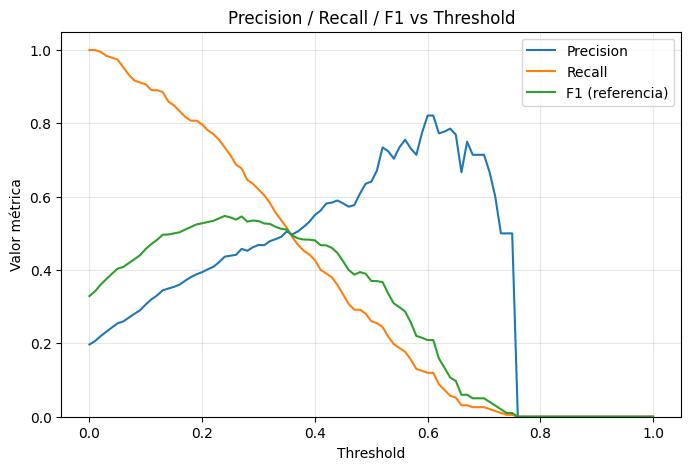

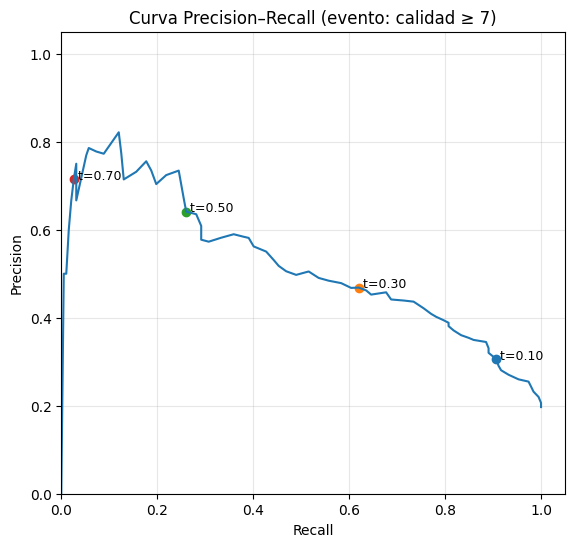

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de tener pr_df ya creado en 5.3 con columnas: threshold, precision, recall, f1

# --- 1) Precision y Recall vs threshold ---
plt.figure(figsize=(8, 5))
plt.plot(pr_df["threshold"], pr_df["precision"], label="Precision")
plt.plot(pr_df["threshold"], pr_df["recall"], label="Recall")
plt.plot(pr_df["threshold"], pr_df["f1"], label="F1 (referencia)")
plt.title("Precision / Recall / F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Valor métrica")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 2) Curva Precision–Recall (trade-off directo) ---
plt.figure(figsize=(6.5, 6))
plt.plot(pr_df["recall"], pr_df["precision"])
plt.title("Curva Precision–Recall (evento: calidad ≥ 7)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

# (Opcional) marcar algunos thresholds para interpretar visualmente
for t_mark in [0.1, 0.3, 0.5, 0.7]:
    row = pr_df.iloc[(pr_df["threshold"] - t_mark).abs().argmin()]
    plt.scatter(row["recall"], row["precision"])
    plt.text(row["recall"], row["precision"], f" t={row['threshold']:.2f}", fontsize=9)

plt.show()

> Estas gráficas muestran de forma visual el **trade-off inevitable** entre *precision*, *recall* y *threshold* cuando convertimos una probabilidad en una decisión.
>
> **Gráfica superior (métricas vs threshold):**
> Al aumentar el threshold, el modelo se vuelve más exigente:
>
> * la **precision** sube: acepta menos vinos, pero con mayor calidad,
> * el **recall** baja: empieza a dejar fuera vinos realmente buenos,
> * el **F1** alcanza un máximo intermedio y luego cae, mostrando que no existe un óptimo estable.
>
> Esto deja claro que no hay un threshold “correcto” desde lo técnico: cada punto representa un **compromiso distinto entre tipos de error**.
>
> **Gráfica inferior (curva Precision–Recall):**
> Cada punto de la curva corresponde a un threshold distinto.
> Moverse hacia la derecha aumenta el recall (se capturan más vinos buenos), pero reduce la precision (se aceptan más vinos no buenos).
> Moverse hacia arriba hace lo contrario: menos aceptaciones, pero más confiables.
>
> Los puntos marcados (t = 0.10, 0.30, 0.50, 0.70) ilustran políticas distintas, no mejoras técnicas.
>
> 📌 Estas curvas no dicen *qué threshold usar*.
> 📌 Muestran **qué se sacrifica y qué se gana** en cada elección.
> **La decisión final es de negocio, no del modelo.**


---
---
---